## 1. Data Integrity Checks

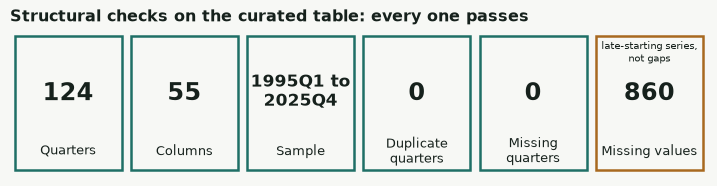

In [2]:
# EDA sees only quarters up to the forecast origin; later quarters are held out for benchmarking.
df = restrict_to_eda_window(pd.read_csv(DATA_PATH))
df['quarter_period'] = pd.PeriodIndex(df['quarter'], freq='Q')
df['quarter_start'] = df['quarter_period'].dt.to_timestamp(how='start')
df = df.sort_values('quarter_period').reset_index(drop=True)

# src.features owns these rate-change transforms for future curated rebuilds.
# Keep this compatibility block so the current checked-in curated CSV can still
# execute before the generated dataset is refreshed. Rate levels are percentages,
# so differences are percentage-point moves rather than proportional log changes.
RATE_CHANGE_LAG_MAP = {
    'cash_rate': [1],
    'unemployment_rate': [1, 2],
}
for source_col, lags in RATE_CHANGE_LAG_MAP.items():
    if source_col not in df:
        continue
    change_col = f'{source_col}_change'
    df[change_col] = df[source_col].diff()
    for lag in lags:
        df[f'{change_col}_lag{lag}'] = df[change_col].shift(lag)

if {'cpi_yoy', 'trimmed_mean_cpi_yoy'}.issubset(df.columns):
    df['headline_trimmed_mean_yoy_gap'] = df['cpi_yoy'] - df['trimmed_mean_cpi_yoy']

df_model = df.drop(columns=['quarter_period', 'quarter_start'])

schema = pd.DataFrame({'column': df_model.columns, 'dtype': df_model.dtypes.astype(str).values})

validation_records = [record.as_dict() for record in validate_curated_dataset(df_model)]
validation_records.append(validate_curated_with_pandera(df_model).as_dict())
validation_summary = pd.DataFrame(validation_records)

quarters = df['quarter_period']
expected_quarters = pd.period_range(quarters.min(), quarters.max(), freq='Q')
integrity_summary = pd.DataFrame([
    {'check': 'row_count', 'value': len(df)},
    {'check': 'column_count', 'value': len(df_model.columns)},
    {'check': 'start_quarter', 'value': str(quarters.min())},
    {'check': 'end_quarter', 'value': str(quarters.max())},
    {'check': 'duplicate_quarters', 'value': int(df['quarter'].duplicated().sum())},
    {'check': 'missing_quarters', 'value': int(len(expected_quarters.difference(quarters)))},
    {'check': 'is_sorted', 'value': bool(quarters.is_monotonic_increasing)},
])
with plt.rc_context(BOOK_STYLE):
    kv = dict(zip(integrity_summary["check"], integrity_summary["value"]))
    n_missing_values = int(validation_summary.loc[0, "missing_values"])
    tiles = [
        ("Quarters", f"{kv['row_count']}", ACCENT),
        ("Columns", f"{kv['column_count']}", ACCENT),
        ("Sample", f"{kv['start_quarter']} to\n{kv['end_quarter']}", ACCENT),
        ("Duplicate\nquarters", f"{kv['duplicate_quarters']}", ACCENT),
        ("Missing\nquarters", f"{kv['missing_quarters']}", ACCENT),
        ("Missing values", f"{n_missing_values}", HIGHLIGHT),
    ]
    fig, ax = plt.subplots(figsize=(9.0, 1.9))
    ax.set_xlim(0, len(tiles)); ax.set_ylim(0, 1); ax.axis("off")
    for i, (label, value, colour) in enumerate(tiles):
        ax.add_patch(plt.Rectangle((i + 0.04, 0.04), 0.92, 0.92, facecolor=PAPER, edgecolor=colour, linewidth=1.8))
        ax.text(i + 0.5, 0.58, value, ha="center", va="center", fontsize=17 if "\n" not in value else 12.5,
                fontweight="bold", linespacing=1.1)
        ax.text(i + 0.5, 0.17, label, ha="center", va="center", fontsize=9)
    ax.text(5.5, 0.93, "late-starting series,\nnot gaps", ha="center", va="top", fontsize=7.5, color=INK)
    ax.set_title("Structural checks on the curated table: every one passes", loc="left", fontsize=11.5, fontweight="bold")
    plt.show()

**Interpretation.** Every structural check passes: 124 quarters from 1995Q1 to 2025Q4,
zero duplicate or missing quarters, correctly sorted, and every core column (`cpi_yoy`,
`cash_rate`, etc.) individually validated `PASS`. The 860 missing *values* flagged above aren't a data-quality failure; they're columns that simply don't exist yet
at the start of the sample (e.g. `wage_price_index` only has 114 of 124 possible
observations, since ABS wage-price data collection started later than CPI). That's exactly
what §2 quantifies next, variable by variable.